# 08. PyMC 実践 — モデルを書けばサンプラーはついてくる

## この章で分かること

- **PyMC** の基本構文: モデル定義 → `pm.sample()` → ArviZ で診断
- 収束診断の読み方: **trace plot・R-hat・有効サンプルサイズ (ESS)**
- **事後予測チェック (PPC)** の最初の一歩
- 03 / 05 / 06 章のモデルを PyMC で再構築し、**閉形式と一致** することを確認

ここまでに自作した部品(共役更新・MH・shrinkage)が、PyMC では数行になります。
仕組みを知った上で道具に乗り換える — それがこの章です。

> **環境メモ**: この Notebook は pytensor の **numba バックエンド** を使います
> (C コンパイラ用の Python ヘッダが無い環境でも動くため)。
> PyMC 自体が無い環境では、各セルは案内を表示してスキップします(README 参照)。

In [1]:
# Setup: numba backend flags MUST be set before pymc/pytensor is imported.
import os

os.environ.setdefault("PYTENSOR_FLAGS", "cxx=,mode=NUMBA")

import matplotlib.pyplot as plt
import numpy as np
import plotly.io as pio

from bayes_textbook.conjugacy import BetaBinomial
from bayes_textbook.models import BayesianLinearRegression, fit_partial_pooling_beta
from bayes_textbook.simulation import make_store_conversions

pio.renderers.default = "plotly_mimetype+notebook_connected"
rng = np.random.default_rng(42)
np.set_printoptions(precision=4, suppress=True)

try:
    import arviz as az
    import pymc as pm

    PYMC_OK = True
    print(f"pymc {pm.__version__} / arviz {az.__version__} ready")
except Exception as err:  # noqa: BLE001 - any failure -> graceful skip mode
    PYMC_OK = False
    print(f"PyMC unavailable ({type(err).__name__}: {err})")
    print("-> install with: uv sync  (or pip install pymc arviz)")
    print("-> the rest of this notebook will print skip notices instead of sampling")

SAMPLE_KW = dict(draws=500, tune=500, chains=2, cores=1, random_seed=42,
                 progressbar=False)

pymc 6.0.1 / arviz 1.1.0 ready


## 1. 最初のモデル — ベータ二項を PyMC で

PyMC のモデルは「数式をほぼそのまま書き写す」形になります。

```text
with pm.Model():
    theta = pm.Beta("theta", 2, 2)        # 事前分布
    pm.Binomial("x", n=50, p=theta, observed=33)   # 尤度(データを observed で渡す)
    idata = pm.sample()                    # 事後からサンプリング(既定は NUTS)
```

03 章の閉形式 $\mathrm{Beta}(2+33,\ 2+17)$ と突き合わせます。

In [2]:
# Beta-binomial in PyMC vs the closed form from ch.03.
exact = BetaBinomial(2, 2).update(33, 17)

if PYMC_OK:
    with pm.Model() as coin_model:
        theta = pm.Beta("theta", alpha=2, beta=2)
        pm.Binomial("x", n=50, p=theta, observed=33)
        idata_coin = pm.sample(**SAMPLE_KW)

    post = idata_coin.posterior["theta"].values.ravel()
    print(f"PyMC  : mean={post.mean():.4f}, sd={post.std():.4f}")
    print(f"exact : mean={exact.mean:.4f}, sd={exact.dist.std():.4f}")
else:
    print("[skipped: PyMC not available]  exact posterior:",
          f"Beta({exact.alpha:g}, {exact.beta:g}), mean={exact.mean:.4f}")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [theta]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


PyMC  : mean=0.6447, sd=0.0623
exact : mean=0.6481, sd=0.0644


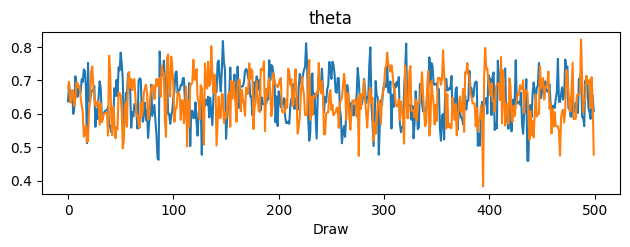

In [3]:
# ArviZ trace plot: chains on the right, marginal density on the left.
if PYMC_OK:
    az.plot_trace(idata_coin)
    plt.tight_layout()
    plt.show()
else:
    print("[skipped: PyMC not available]")

### 事前感度を PyMC で総当たりする(スライダー)

numba バックエンドではサンプリングが一瞬なので、
事前分布を変えながら何度も再サンプリングする「感度分析」が気軽にできます。
各フレームで PyMC の事後(実線)と閉形式(破線)が重なることも同時に確認できます。

In [4]:
# Prior sensitivity sweep, each frame re-sampled with PyMC (instant with numba).
from bayes_textbook import visualization as viz

if PYMC_OK:
    theta_grid = np.linspace(0.3, 0.9, 200)
    frames = []
    for a, b in [(1, 1), (2, 2), (8, 2), (20, 20), (50, 50)]:
        with pm.Model():
            th = pm.Beta("theta", a, b)
            pm.Binomial("x", n=50, p=th, observed=33)
            id_ = pm.sample(**SAMPLE_KW)
        smp = id_.posterior["theta"].values.ravel()
        hist, edges = np.histogram(smp, bins=40, range=(0.3, 0.9), density=True)
        centers = 0.5 * (edges[:-1] + edges[1:])
        exact_pdf = BetaBinomial(a, b).update(33, 17).dist.pdf(theta_grid)
        frames.append((f"Beta({a},{b})",
                       [("PyMC posterior", np.interp(theta_grid, centers, hist), None),
                        ("exact posterior", exact_pdf, "dash")]))
    fig = viz.plotly_curve_slider(theta_grid, frames, slider_name="prior",
                                  title="prior sensitivity, re-sampled live with PyMC")
    fig.update_xaxes(title="theta")
    fig.show()
else:
    print("[skipped: PyMC not available]")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [theta]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [theta]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


## 2. 収束診断 — R-hat と ESS

`az.summary` の必読列:

- **r_hat**: 複数チェーンの「分散の比」。**1.00〜1.01 なら合格**、1.05 超は危険信号
  (チェーン同士が違う場所を歩いている)。
- **ess_bulk / ess_tail**: 自己相関を割り引いた **実質サンプル数**(07 章の自己相関の正体)。
  数百あれば平均・区間の推定には十分。

In [5]:
# Convergence summary: r_hat ~ 1.00 and healthy ESS mean the sampler mixed well.
if PYMC_OK:
    print(az.summary(idata_coin, var_names=["theta"]).to_string())
else:
    print("[skipped: PyMC not available]")

        mean     sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat mcse_mean mcse_sd
theta  0.645  0.062     0.55     0.74       371       494  1.00    0.0032  0.0023


## 3. ベイズ線形回帰 — 今度はノイズ分散も推定する

05 章では閉形式のために $\sigma$ を既知としました。PyMC ならその制約は不要 —
$\sigma$ に事前分布(HalfNormal)を置いて **係数と同時に推定** します。

In [6]:
# Bayesian linear regression with UNKNOWN noise sigma (impossible in ch.05's closed form).
true_w = np.array([0.8, 1.4])
x_data = np.sort(rng.uniform(-3, 3, 60))
y_data = true_w[0] + true_w[1] * x_data + 1.0 * rng.standard_normal(60)

if PYMC_OK:
    with pm.Model() as reg_model:
        w0 = pm.Normal("w0", 0, 10)
        w1 = pm.Normal("w1", 0, 10)
        sigma = pm.HalfNormal("sigma", 2)
        pm.Normal("y", mu=w0 + w1 * x_data, sigma=sigma, observed=y_data)
        idata_reg = pm.sample(**SAMPLE_KW)

    print(az.summary(idata_reg, var_names=["w0", "w1", "sigma"]).to_string())

    # Cross-check the weights against the ch.05 closed form (sigma fixed at 1).
    X = np.column_stack([np.ones_like(x_data), x_data])
    blr = BayesianLinearRegression(sigma=1.0, sigma_w=10.0).fit(X, y_data)
    print(f"\nclosed form (sigma known): w = {blr.w_mean}")
else:
    print("[skipped: PyMC not available]")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [w0, w1, sigma]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


        mean     sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat mcse_mean mcse_sd
w0     0.596  0.099     0.44     0.75      1347       674  1.00    0.0027  0.0021
w1     1.356  0.061      1.3      1.5      1202       694  1.00    0.0018  0.0013
sigma  0.769  0.075     0.66      0.9      1447       753  1.00     0.002  0.0015

closed form (sigma known): w = [0.5982 1.3546]


$\sigma$ の事後(真値 1.0 付近)まで一度に手に入りました。
「閉形式の都合でモデルを曲げる」必要がなくなるのが PPL(確率的プログラミング言語)の価値です。

## 4. 階層ベイズ — フルベイズで店舗 CVR

06 章の経験ベイズでは、共通事前 $\mathrm{Beta}(\alpha_0, \beta_0)$ をデータから **点推定** しました。
PyMC なら $\alpha_0, \beta_0$(を変換した平均 $\mu$ と擬似データ数 $\kappa$)にも事前を置く
**フルベイズ** にできます。ハイパーパラメータの不確実性まで事後に乗ります。

In [7]:
# Full-Bayes hierarchical binomial: hyperprior on the shared Beta prior.
stores = make_store_conversions(n_stores=12, seed=42)
eb = fit_partial_pooling_beta(stores["conversions"], stores["visits"])   # ch.06 baseline

if PYMC_OK:
    with pm.Model() as hier_model:
        mu = pm.Beta("mu", 2, 2)                      # population mean rate
        kappa = pm.Gamma("kappa", 2, 0.01)            # concentration (pseudo-visits)
        theta = pm.Beta("theta", alpha=mu * kappa, beta=(1 - mu) * kappa,
                        shape=len(stores))
        pm.Binomial("conv", n=stores["visits"].to_numpy(), p=theta,
                    observed=stores["conversions"].to_numpy())
        idata_hier = pm.sample(target_accept=0.9, **SAMPLE_KW)

    theta_mean = idata_hier.posterior["theta"].mean(dim=("chain", "draw")).values
    print("store   raw     EB-partial  full-Bayes")
    raw = (stores["conversions"] / stores["visits"]).to_numpy()
    for i in range(len(stores)):
        print(f"{stores['store'][i]}   {raw[i]:.4f}   {eb.partial[i]:.4f}     {theta_mean[i]:.4f}")
    print(f"\nr_hat max = {float(az.summary(idata_hier)['r_hat'].max()):.3f}")
else:
    print("[skipped: PyMC not available]  EB partial-pooling estimates:", eb.partial.round(4))

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [mu, kappa, theta]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


store   raw     EB-partial  full-Bayes
S00   0.0378   0.0418     0.0439
S01   0.0332   0.0354     0.0370
S02   0.0543   0.0573     0.0572
S03   0.0968   0.0760     0.0686
S04   0.0373   0.0432     0.0459
S05   0.1111   0.0733     0.0663
S06   0.0657   0.0655     0.0646
S07   0.0529   0.0546     0.0549
S08   0.0628   0.0628     0.0622
S09   0.0424   0.0516     0.0530
S10   0.0768   0.0763     0.0755
S11   0.0757   0.0751     0.0740

r_hat max = 1.010


経験ベイズ(06 章)とフルベイズの店舗別推定はほぼ一致 —
グループ数が十分ある今回は、点推定したハイパーパラメータで十分だったと **確認できた** ことになります。
(グループ数が少ないときに差が出ます。)

## 5. 事後予測チェック(PPC)— モデルはデータを再現できるか

事後からパラメータを引き、そのパラメータでデータを生成し直し、実データと比べる。
`pm.sample_posterior_predictive` が一発でやってくれます。詳しい使い方は 09 章の主題。

Sampling: [y]


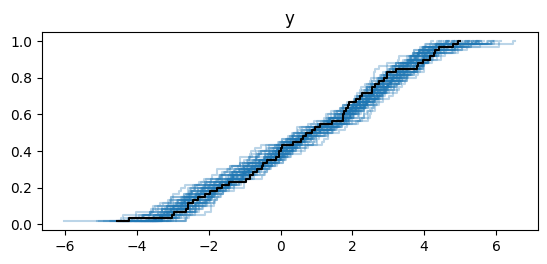

In [8]:
# Posterior predictive check for the regression model.
# (ArviZ 1.x renamed plot_ppc -> plot_ppc_dist.)
if PYMC_OK:
    with reg_model:
        ppc = pm.sample_posterior_predictive(idata_reg, random_seed=42,
                                             progressbar=False)
    az.plot_ppc_dist(ppc)
    plt.show()
else:
    print("[skipped: PyMC not available]")

## 6. Failure Mode — PyMC でよく踏む地雷

- **r_hat が悪いのに結果を使う**: サンプルは「事後の絵」になっていない。
  `target_accept` を上げる・再パラメータ化(階層モデルの non-centered 化)が定石。
- **divergence 警告の無視**: NUTS が地形を踏み外したサイン。特に階層モデルで頻出。
- **observed の形状ミス**: ブロードキャストで黙って意図と違うモデルになることがある。
  `model.debug()` や `pm.model_to_graphviz` で確認する習慣を。
- **巨大データへの素朴な適用**: MCMC は万能ではない。変分推論(ADVI)やミニバッチ化も選択肢。

## 7. まとめ

- PyMC は「数式をそのまま書く」: 事前 = 分布オブジェクト、尤度 = `observed` 付き分布。
- `pm.sample()` の既定は NUTS(07 章の HMC の自動チューニング版)。
- 診断は **trace・r_hat(≦1.01)・ESS** をまず見る。
- 閉形式(03/05/06 章)と一致することを確認した — 以後は閉形式が無いモデルでも安心して書ける。
- ノイズ分散の同時推定・フルベイズ階層化など、**閉形式の檻の外** が PPL の主戦場。

## 8. Exercises

1. §1 のモデルで事前を $\mathrm{Beta}(20, 20)$ に変え、事後平均の変化を閉形式と照合せよ。
2. §3 で `draws=2000` に増やし、ESS と要約統計の安定性がどう変わるか確認せよ。
3. §3 の回帰に 2 次項 `w2 * x**2` を足してサンプリングし、`w2` の事後が 0 を含むことを確認せよ。
4. §4 の階層モデルで `kappa` の事後分布をプロットし、06 章の経験ベイズの
   `prior_strength` 推定値と比較せよ。
5. (発展)§4 を non-centered 化(`theta_raw ~ Beta` の代わりにロジットスケールの
   `Normal` + 変換)で書き直し、divergence が減るか確認せよ。